<a href="https://colab.research.google.com/github/CarlosJB95/PathIA-MSI-colon/blob/main/Notebook_03_pandas_manifest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Semana 2 · Día 8 — pandas sobre el manifest**
Objetivo: cargar/crear el manifest como DataFrame, explorarlo (head, dtypes, describe) y filtrarlo.
Puente: una lista de dicts (Notebook 02) → un DataFrame (tabla de la cohorte).

---



In [1]:
import numpy as np
import pandas as pd
np.random.seed(42)

def filtrar_parche(patch, umbral=220):
    gris = patch.mean(axis=2)
    pct  = float((gris < umbral).mean() * 100)
    m    = patch.astype(np.float32).mean(axis=(0, 1))
    return {"pct_tejido": round(pct, 1),
            "media_R": round(float(m[0]), 1),
            "media_G": round(float(m[1]), 1),
            "media_B": round(float(m[2]), 1),
            "conservar": pct >= 50}

filas = []
for k in range(12):
    p = np.random.randint(0, 256, size=(8, 8, 3), dtype=np.uint8)
    n_fondo = k % 8                       # 0 a 7 filas de fondo → variedad
    if n_fondo:
        p[:n_fondo, :] = 245
    fila = {"slide_id": f"TCGA-{k // 4:02d}", "patch_id": f"p{k:03d}", **filtrar_parche(p)}
    filas.append(fila)

df = pd.DataFrame(filas)     # ← EL PUENTE: lista de dicts → DataFrame
df

,slide_id,patch_id,pct_tejido,media_R,media_G,media_B,conservar
0,TCGA-00,p000,98.4,140.4,139.7,118.7,True
1,TCGA-00,p001,85.9,132.0,146.3,125.3,True
2,TCGA-00,p002,73.4,149.7,159.0,143.5,True
3,TCGA-00,p003,62.5,163.7,176.0,172.9,True
4,TCGA-01,p004,50.0,180.9,184.1,186.2,True
5,TCGA-01,p005,37.5,199.5,203.7,202.2,False
6,TCGA-01,p006,25.0,221.7,206.9,213.9,False
7,TCGA-01,p007,12.5,229.6,236.1,230.6,False
8,TCGA-02,p008,98.4,130.5,135.2,134.0,True
9,TCGA-02,p009,87.5,147.4,140.5,142.3,True


In [2]:
print(df.shape)      # (12, 7)
df.head()            # primeras 5 filas — como asomarte a la laminilla antes de contarla toda

(12, 7)


,slide_id,patch_id,pct_tejido,media_R,media_G,media_B,conservar
0,TCGA-00,p000,98.4,140.4,139.7,118.7,True
1,TCGA-00,p001,85.9,132.0,146.3,125.3,True
2,TCGA-00,p002,73.4,149.7,159.0,143.5,True
3,TCGA-00,p003,62.5,163.7,176.0,172.9,True
4,TCGA-01,p004,50.0,180.9,184.1,186.2,True


In [3]:
df.describe()

,pct_tejido,media_R,media_G,media_B
count,12.000000,12.000000,12.000000,12.000000
mean,64.050000,168.275000,170.208333,167.208333
std,28.097088,33.335979,31.760280,36.068709
min,12.500000,130.500000,135.200000,118.700000
25%,46.875000,145.650000,144.850000,140.225000
50%,67.950000,159.800000,158.500000,167.200000
75%,86.300000,185.550000,189.000000,190.200000
max,98.400000,229.600000,236.100000,230.600000


In [4]:
df["conservar"]          # una Serie de True/False, una por fila → ¡es una máscara booleana!
df[df["conservar"]]      # quédate solo con las filas donde la máscara es True

,slide_id,patch_id,pct_tejido,media_R,media_G,media_B,conservar
0,TCGA-00,p000,98.4,140.4,139.7,118.7,True
1,TCGA-00,p001,85.9,132.0,146.3,125.3,True
2,TCGA-00,p002,73.4,149.7,159.0,143.5,True
3,TCGA-00,p003,62.5,163.7,176.0,172.9,True
4,TCGA-01,p004,50.0,180.9,184.1,186.2,True
8,TCGA-02,p008,98.4,130.5,135.2,134.0,True
9,TCGA-02,p009,87.5,147.4,140.5,142.3,True
10,TCGA-02,p010,75.0,155.9,157.0,161.5,True
11,TCGA-02,p011,62.5,168.0,158.0,175.4,True


In [5]:
conservables = df[df["pct_tejido"] >= 50]     # máscara al vuelo (mismo criterio)
print("Total parches:", len(df))
print("Conservables :", len(conservables))
descartados = len(df) - len(conservables)
print("Descartados  :", descartados)

Total parches: 12
Conservables : 9
Descartados  : 3


In [6]:
conservables.to_csv("manifest_conservables.csv", index=False)

# releer y confirmar que NO apareció ninguna columna 'Unnamed'
check = pd.read_csv("manifest_conservables.csv")
print(check.shape)        # (9, 7)  → 9 conservables, 7 columnas (sin basura)
print(check.columns.tolist())

(9, 7)
['slide_id', 'patch_id', 'pct_tejido', 'media_R', 'media_G', 'media_B', 'conservar']


In [7]:
df.iloc[:3]                    # (a) primeras 3 filas por POSICIÓN
df.loc[0, "pct_tejido"]        # (b) valor en etiqueta de fila 0, columna "pct_tejido"
df.loc[df.pct_tejido > 25]     # (c) filtrado booleano por etiqueta

,slide_id,patch_id,pct_tejido,media_R,media_G,media_B,conservar
0,TCGA-00,p000,98.4,140.4,139.7,118.7,True
1,TCGA-00,p001,85.9,132.0,146.3,125.3,True
2,TCGA-00,p002,73.4,149.7,159.0,143.5,True
3,TCGA-00,p003,62.5,163.7,176.0,172.9,True
4,TCGA-01,p004,50.0,180.9,184.1,186.2,True
5,TCGA-01,p005,37.5,199.5,203.7,202.2,False
8,TCGA-02,p008,98.4,130.5,135.2,134.0,True
9,TCGA-02,p009,87.5,147.4,140.5,142.3,True
10,TCGA-02,p010,75.0,155.9,157.0,161.5,True
11,TCGA-02,p011,62.5,168.0,158.0,175.4,True


In [8]:
print(df.iloc[:3].shape)         # (3, 7) → DataFrame
print(len(df.iloc[0:3]))         # 3  (exclusivo)  ✓ tu predicción
print(len(df.loc[0:3]))          # 4  (inclusivo)  ✓ tu predicción
print(df.loc[0, "pct_tejido"])   # un valor escalar

(3, 7)
3
4
98.4


In [9]:
solo_A     = df[df.pct_tejido > 25]
ambas      = df[(df.pct_tejido > 25) & (df.media_R < 150)]

print("solo pct_tejido>25:", len(solo_A))
print("ambas condiciones :", len(ambas))
print("cota A∩B ⊆ A:", len(ambas) <= len(solo_A))   # True, siempre

solo pct_tejido>25: 10
ambas condiciones : 5
cota A∩B ⊆ A: True


In [10]:
# Asignación: una comparación (máscara booleana) SE VUELVE una columna nueva.
# Usamos un nombre NUEVO para no pisar el criterio oficial `conservar` (pct >= 50).
df["conservar_25"] = df.pct_tejido > 25          # umbral alternativo (Kaggle L2)

print(df["conservar_25"].dtype)                  # bool
print((df.pct_tejido > 25).dtype)                # bool  ← una comparación SIEMPRE da bool
print(df.dtypes)                                 # cada columna en su casilla: object / float64 / bool

bool
bool
slide_id         object
patch_id         object
pct_tejido      float64
media_R         float64
media_G         float64
media_B         float64
conservar          bool
conservar_25       bool
dtype: object


In [11]:
# value_counts devuelve una Serie: el índice son las categorías, los valores son los conteos
print(df["conservar"].value_counts())   # True 9 / False 3  (criterio oficial pct>=50)
print()
print(df["slide_id"].value_counts())    # 4 parches por laminilla × 3 laminillas

conservar
True     9
False    3
Name: count, dtype: int64

slide_id
TCGA-00    4
TCGA-01    4
TCGA-02    4
Name: count, dtype: int64


In [12]:
df["slide_id"].unique()      # ¿QUÉ valores distintos hay? → array(['TCGA-00','TCGA-01','TCGA-02'])
df["slide_id"].nunique()     # ¿CUÁNTOS valores distintos hay? → 3

3

In [13]:
print("laminillas distintas :", df["slide_id"].nunique())      # 3
print("pct_tejido distintos :", df["pct_tejido"].nunique())    # ¿12? ¿o menos por empates?
print("total de filas       :", len(df))                       # 12

laminillas distintas : 3
pct_tejido distintos : 10
total de filas       : 12


In [14]:
df["nivel_tejido"] = df["pct_tejido"].map(
    lambda p: "alto" if p > 50 else "medio" if p > 25 else "bajo"
)
df[["patch_id", "pct_tejido", "nivel_tejido"]]

,patch_id,pct_tejido,nivel_tejido
0,p000,98.4,alto
1,p001,85.9,alto
2,p002,73.4,alto
3,p003,62.5,alto
4,p004,50.0,medio
5,p005,37.5,medio
6,p006,25.0,bajo
7,p007,12.5,bajo
8,p008,98.4,alto
9,p009,87.5,alto


In [15]:
# map NO puede: solo ve pct_tejido, no media_R
# apply SÍ: recibe la fila completa (axis=1 = "por filas")
df["revisar"] = df.apply(
    lambda fila: "sí" if (fila["pct_tejido"] > 50 and fila["media_R"] > 160) else "no",
    axis=1
)

In [16]:
df.sort_values("pct_tejido", ascending=False)

,slide_id,patch_id,pct_tejido,media_R,media_G,media_B,conservar,conservar_25,nivel_tejido,revisar
0,TCGA-00,p000,98.4,140.4,139.7,118.7,True,True,alto,no
8,TCGA-02,p008,98.4,130.5,135.2,134.0,True,True,alto,no
9,TCGA-02,p009,87.5,147.4,140.5,142.3,True,True,alto,no
1,TCGA-00,p001,85.9,132.0,146.3,125.3,True,True,alto,no
10,TCGA-02,p010,75.0,155.9,157.0,161.5,True,True,alto,no
2,TCGA-00,p002,73.4,149.7,159.0,143.5,True,True,alto,no
3,TCGA-00,p003,62.5,163.7,176.0,172.9,True,True,alto,sí
11,TCGA-02,p011,62.5,168.0,158.0,175.4,True,True,alto,sí
4,TCGA-01,p004,50.0,180.9,184.1,186.2,True,True,medio,no
5,TCGA-01,p005,37.5,199.5,203.7,202.2,False,True,medio,no


In [17]:
df.query("pct_tejido > 25 and media_R < 150") #'query' gana en legibilidad cuando la condición es larga o la compartes con alguien (se lee casi como español)

,slide_id,patch_id,pct_tejido,media_R,media_G,media_B,conservar,conservar_25,nivel_tejido,revisar
0,TCGA-00,p000,98.4,140.4,139.7,118.7,True,True,alto,no
1,TCGA-00,p001,85.9,132.0,146.3,125.3,True,True,alto,no
2,TCGA-00,p002,73.4,149.7,159.0,143.5,True,True,alto,no
8,TCGA-02,p008,98.4,130.5,135.2,134.0,True,True,alto,no
9,TCGA-02,p009,87.5,147.4,140.5,142.3,True,True,alto,no


In [18]:
# ~ = NOT: invierte la máscara → los parches que NO se conservan (descartados por el criterio oficial pct>=50)
df[~df["conservar"]][["patch_id", "pct_tejido", "conservar"]]   # pct < 50 → p005 (37.5), p006 (25.0), p007 (12.5)

,patch_id,pct_tejido,conservar
5,p005,37.5,False
6,p006,25.0,False
7,p007,12.5,False


In [19]:
def explorar_manifest(df):
    """Imprime una radiografía EDA del manifest: forma, tipos, resumen y % conservables."""
    print("Forma (filas, columnas):", df.shape)
    print("\nTipos por columna:")
    print(df.dtypes)
    print("\nResumen numérico:")
    print(df.describe())
    print("\n% de parches conservables:", round(df["conservar"].mean() * 100, 1))

explorar_manifest(df)

Forma (filas, columnas): (12, 10)

Tipos por columna:
slide_id         object
patch_id         object
pct_tejido      float64
media_R         float64
media_G         float64
media_B         float64
conservar          bool
conservar_25       bool
nivel_tejido     object
revisar          object
dtype: object

Resumen numérico:
       pct_tejido     media_R     media_G     media_B
count   12.000000   12.000000   12.000000   12.000000
mean    64.050000  168.275000  170.208333  167.208333
std     28.097088   33.335979   31.760280   36.068709
min     12.500000  130.500000  135.200000  118.700000
25%     46.875000  145.650000  144.850000  140.225000
50%     67.950000  159.800000  158.500000  167.200000
75%     86.300000  185.550000  189.000000  190.200000
max     98.400000  229.600000  236.100000  230.600000

% de parches conservables: 75.0


In [20]:
df.groupby("slide_id")["pct_tejido"].mean()

,pct_tejido
slide_id,
TCGA-00,80.05
TCGA-01,31.25
TCGA-02,80.85


In [21]:
df.groupby("slide_id")["pct_tejido"].agg(["mean", "count", "std", "min", "max"])

,mean,count,std,min,max
slide_id,,,,,
TCGA-00,80.05,4,15.526000,62.5,98.4
TCGA-01,31.25,4,16.137431,12.5,50.0
TCGA-02,80.85,4,15.526000,62.5,98.4


In [22]:
df.loc[3, "media_R"] = np.nan     # simulamos un hueco: al parche p003 le "falta" media_R

In [23]:
df.isnull()              # DataFrame de True/False: True donde hay NaN
df["media_R"].isnull()   # por columna: ¿qué filas tienen NaN en media_R?

,media_R
0,False
1,False
2,False
3,True
4,False
5,False
6,False
7,False
8,False
9,False


In [24]:
df.isnull().sum()        # cuántos NaN por columna

,0
slide_id,0
patch_id,0
pct_tejido,0
media_R,1
media_G,0
media_B,0
conservar,0
conservar_25,0
nivel_tejido,0
revisar,0


In [25]:
# El NaN ya está puesto arriba; aquí solo lo observamos
print(df.isnull().sum())                                  # media_R: 1
print("media global media_R:", df["media_R"].mean())      # promedia 11 valores (NaN omitido)
print(df.groupby("slide_id")["media_R"].agg(["mean", "count"]))   # TCGA-00 count=3, resto 4

slide_id        0
patch_id        0
pct_tejido      0
media_R         1
media_G         0
media_B         0
conservar       0
conservar_25    0
nivel_tejido    0
revisar         0
dtype: int64
media global media_R: 168.69090909090912
             mean  count
slide_id                
TCGA-00   140.700      3
TCGA-01   207.925      4
TCGA-02   150.450      4


In [26]:
df.dropna()                          # ELIMINAR las filas con algún NaN
df["media_R"].fillna(df["media_R"].mean())   # RELLENAR el hueco (aquí, con la media)

,media_R
0,140.400000
1,132.000000
2,149.700000
3,168.690909
4,180.900000
5,199.500000
6,221.700000
7,229.600000
8,130.500000
9,147.400000


In [27]:
# imputar media_R con la MEDIANA DE SU PROPIA LAMINILLA (lo más fino para tu estructura)
df["media_R"] = df["media_R"].fillna(
    df.groupby("slide_id")["media_R"].transform("median")
)
print(df.isnull().sum())    # media_R: 0 → hueco cerrado con criterio de grupo

slide_id        0
patch_id        0
pct_tejido      0
media_R         0
media_G         0
media_B         0
conservar       0
conservar_25    0
nivel_tejido    0
revisar         0
dtype: int64


In [28]:
df = df.rename(columns={"media_R": "media_r", "media_G": "media_g", "media_B": "media_b"})

In [29]:
df["conservar"] = df["conservar"].astype(bool)   # asegurar que es bool, no object
df["pct_tejido"] = df["pct_tejido"].astype(float) # asegurar float

In [30]:
def resumir_por_slide(df):
    """Agrega el manifest de parche-level a slide-level: una fila por laminilla.
    Devuelve un DataFrame con nº de parches, % tejido medio y firma de color media."""
    resumen = df.groupby("slide_id").agg(
        n_parches   = ("patch_id",   "count"),
        pct_tejido_medio = ("pct_tejido", "mean"),
        pct_tejido_std   = ("pct_tejido", "std"),
        media_r     = ("media_r",    "mean"),
        media_g     = ("media_g",    "mean"),
        media_b     = ("media_b",    "mean"),
    ).round(1)
    return resumen

manifest_slide = resumir_por_slide(df)
manifest_slide.to_csv("manifest_slide.csv")     # ← ojo: aquí SÍ queremos el índice
print(manifest_slide)

          n_parches  pct_tejido_medio  pct_tejido_std  media_r  media_g  \
slide_id                                                                  
TCGA-00           4              80.1            15.5    140.6    155.2   
TCGA-01           4              31.2            16.1    207.9    207.7   
TCGA-02           4              80.8            15.5    150.4    147.7   

          media_b  
slide_id           
TCGA-00     140.1  
TCGA-01     208.2  
TCGA-02     153.3  


In [31]:
manifest_slide = resumir_por_slide(df)
print(manifest_slide.shape)          # (3, 6) → índice slide_id aparte
manifest_slide.to_csv("manifest_slide.csv")
print(pd.read_csv("manifest_slide.csv").shape)   # (3, 7) → aquí slide_id ya es columna

(3, 6)
(3, 7)


## EDA de instrumento — Titanic
Practicar el gesto de EDA (faltantes, agregación por grupo) sobre un dataset tabular limpio,
con puente explícito a su equivalente en el manifest H&E.

In [32]:
import seaborn as sns
titanic = sns.load_dataset("titanic")   # columnas en minúscula: survived, pclass, sex, age, fare...
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [33]:
titanic.info()            # tipos + cuántos NO-nulos por columna
titanic.describe()        # resumen numérico
titanic.isnull().sum()    # inventario de faltantes por columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


### Manejo de faltantes
Decisión por columna, según *cuánto* falta y *por qué*:
- **`deck`** — 77 % faltante (MNAR: concentrado en 3ª clase) → **eliminar la columna** (demasiado hueca para imputar sin inventar).
- **`age`** — 20 % faltante → **imputar** con la mediana **por grupo** (`sex` × `pclass`), más un colchón global por si algún grupo quedara vacío.
- **`embarked`** — 2 faltantes → **eliminar esas 2 filas** (impacto despreciable).

In [34]:
# deck: 77% faltante (MNAR) → eliminar la columna
titanic = titanic.drop(columns="deck")

# age: 20% faltante → imputar por grupo (sex × pclass) + colchón global
titanic["age"] = titanic["age"].fillna(
    titanic.groupby(["sex", "pclass"])["age"].transform("median")
)
titanic["age"] = titanic["age"].fillna(titanic["age"].median())   # red de seguridad

# embarked: 2 faltantes → eliminar esas filas
titanic = titanic.dropna(subset=["embarked"])

print(titanic.isnull().sum())    # 0 en las columnas tratadas
print("shape:", titanic.shape)   # (889, 14): 891 − 2 filas, sin la columna deck

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64
shape: (889, 14)


### Agregación por grupo — tasa de supervivencia

In [35]:
# El mismo gesto que una "tasa de MSI-H por subgrupo": media de una variable 0/1 por grupo
print("Supervivencia por sexo:")
print(titanic.groupby("sex")["survived"].mean().round(3))
print("\nSupervivencia por clase:")
print(titanic.groupby("pclass")["survived"].mean().round(3))

Supervivencia por sexo:
sex
female    0.740
male      0.189
Name: survived, dtype: float64

Supervivencia por clase:
pclass
1    0.626
2    0.473
3    0.242
Name: survived, dtype: float64


### Puente clínico
El mismo gesto metodológico, sobre la cohorte H&E:
- Faltantes de `age`/`deck` ↔ faltantes de `MPP` / `tumor_pct` — y su **patrón** importa: un faltante MNAR (correlacionado con otra variable) sesga si se ignora.
- `groupby(...).survived.mean()` ↔ **tasa de MSI-H por subgrupo** y agregación **parche → laminilla → paciente**.
- Desbalance de clases (`survived`) ↔ **MSI-H ≈ 15 % del CRC**.

Titanic es el *maniquí*: se practica el gesto en limpio antes de aplicarlo al `manifest_slide.csv` real y a los *splits por paciente* del MIL.

# Semana 3 · Día 11 — **matplotlib**: líneas, barras, dispersión

---



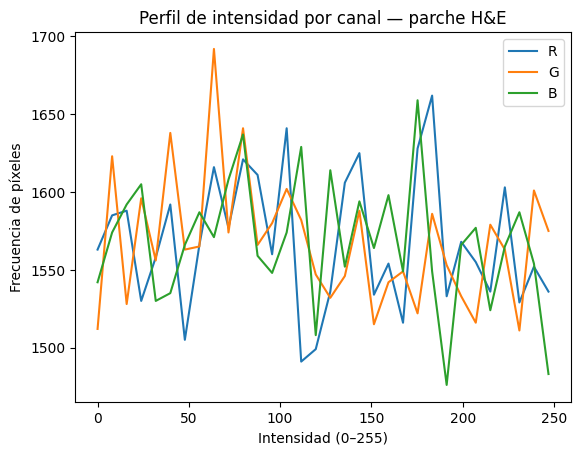

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# parche H&E simulado (o usa un array real del Día 7): (alto, ancho, 3)
parche = np.random.randint(0, 256, size=(224, 224, 3), dtype=np.uint8)

fig, ax = plt.subplots()
for i, canal in enumerate(['R', 'G', 'B']):
    hist, bordes = np.histogram(parche[:, :, i], bins=32, range=(0, 255))
    ax.plot(bordes[:-1], hist, label=canal)

ax.set_title('Perfil de intensidad por canal — parche H&E')
ax.set_xlabel('Intensidad (0–255)')
ax.set_ylabel('Frecuencia de píxeles')
ax.legend()
plt.show()

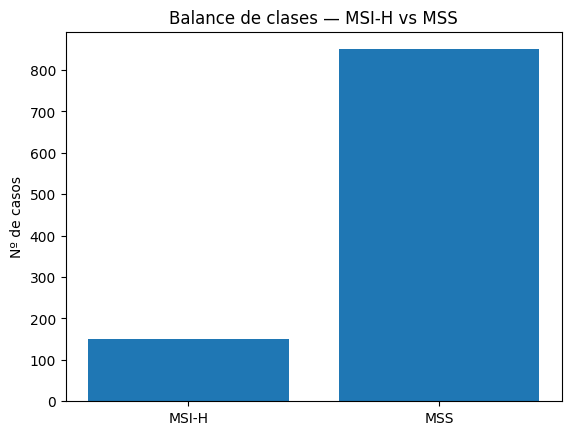

In [37]:
clases = ['MSI-H', 'MSS']
conteos = [150, 850]   # ilustra el desbalance ~15% del CRC

fig, ax = plt.subplots()
ax.bar(clases, conteos)
ax.set_title('Balance de clases — MSI-H vs MSS')
ax.set_ylabel('Nº de casos')
plt.show()

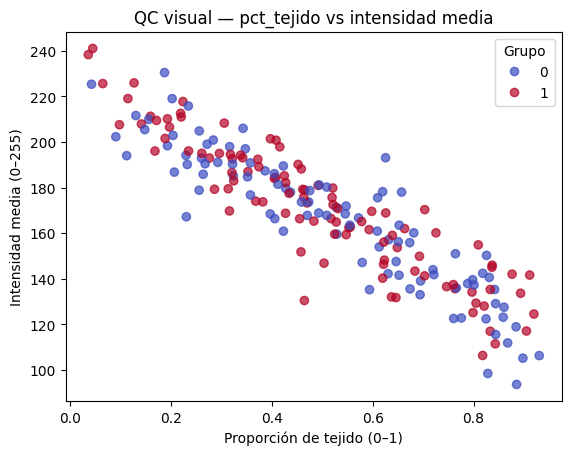

In [38]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)

# simula 200 parches: pct_tejido (0–1) e intensidad media (0–255)
pct_tejido = rng.beta(2, 2, 200)
intensidad = 230 - 120 * pct_tejido + rng.normal(0, 12, 200)  # más tejido → más oscuro
grupo = rng.integers(0, 2, 200)   # 0 = MSS, 1 = MSI-H (ilustrativo)

fig, ax = plt.subplots()
sc = ax.scatter(pct_tejido, intensidad, c=grupo, cmap='coolwarm', alpha=0.7)
ax.set_title('QC visual — pct_tejido vs intensidad media')
ax.set_xlabel('Proporción de tejido (0–1)')
ax.set_ylabel('Intensidad media (0–255)')
ax.legend(*sc.legend_elements(), title='Grupo')
plt.show()

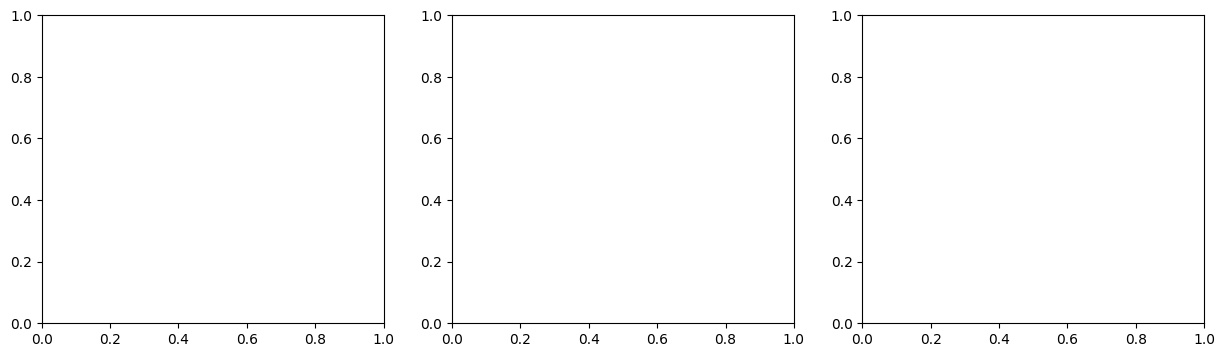

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

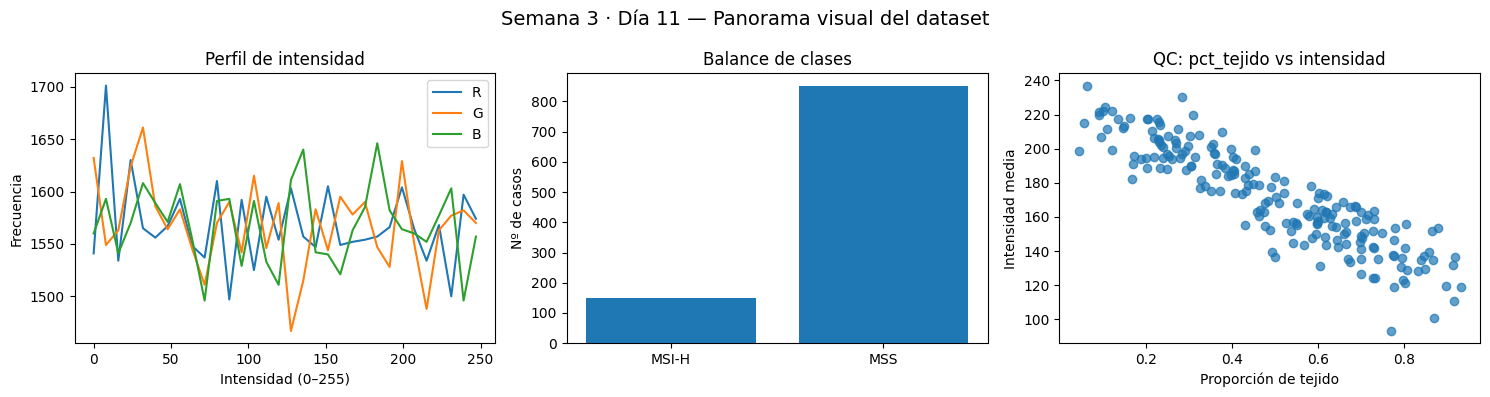

In [40]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Panel 0: líneas (perfil de intensidad) ---
parche = rng.integers(0, 256, size=(224, 224, 3), dtype=np.uint8)
for i, canal in enumerate(['R', 'G', 'B']):
    hist, bordes = np.histogram(parche[:, :, i], bins=32, range=(0, 255))
    axes[0].plot(bordes[:-1], hist, label=canal)
axes[0].set_title('Perfil de intensidad')
axes[0].set_xlabel('Intensidad (0–255)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# --- Panel 1: barras (balance de clases) ---
axes[1].bar(['MSI-H', 'MSS'], [150, 850])
axes[1].set_title('Balance de clases')
axes[1].set_ylabel('Nº de casos')

# --- Panel 2: dispersión (QC visual) ---
pct_tejido = rng.beta(2, 2, 200)
intensidad = 230 - 120 * pct_tejido + rng.normal(0, 12, 200)
axes[2].scatter(pct_tejido, intensidad, alpha=0.7)
axes[2].set_title('QC: pct_tejido vs intensidad')
axes[2].set_xlabel('Proporción de tejido')
axes[2].set_ylabel('Intensidad media')

fig.suptitle('Semana 3 · Día 11 — Panorama visual del dataset', fontsize=14)
fig.tight_layout()
plt.show()

In [41]:
from pathlib import Path

Path('results').mkdir(exist_ok=True)   # crea la carpeta si no existe

fig.savefig(
    'results/dia11_panorama_dataset.png',
    dpi=150,             # resolución: nítido sin ser gigante
    bbox_inches='tight'  # recorta el margen blanco sobrante
)

## **Semana 3 · Día 12 — Histogramas, boxplots y subplots**

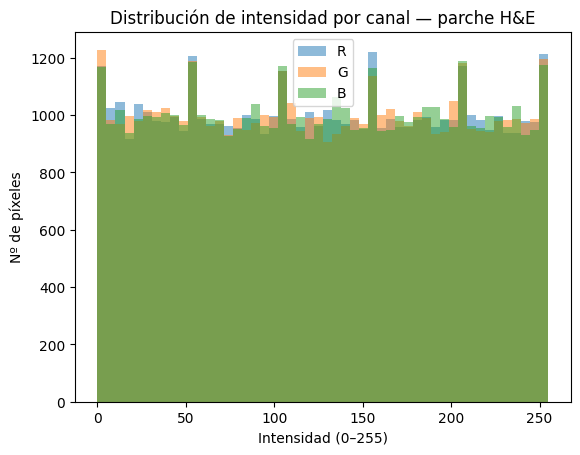

In [42]:
fig, ax = plt.subplots()
for i, canal in enumerate(['R', 'G', 'B']):
    ax.hist(parche[:, :, i].ravel(), bins=50, alpha=0.5, label=canal)
ax.set_title('Distribución de intensidad por canal — parche H&E')
ax.set_xlabel('Intensidad (0–255)')
ax.set_ylabel('Nº de píxeles')
ax.legend()
plt.show()

/tmp/ipykernel_52808/3449890458.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([mss, msih], labels=['MSS', 'MSI-H'])


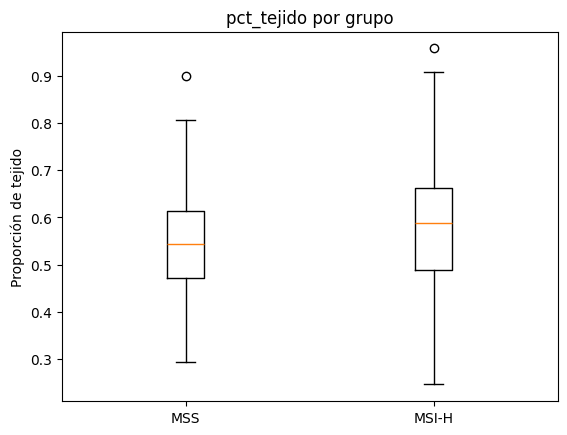

In [43]:
# ilustrativo: pct_tejido simulado para dos grupos
import numpy as np
rng = np.random.default_rng(42)
mss   = rng.normal(0.55, 0.12, 200).clip(0, 1)
msih  = rng.normal(0.58, 0.13, 200).clip(0, 1)

fig, ax = plt.subplots()
ax.boxplot([mss, msih], labels=['MSS', 'MSI-H'])
ax.set_title('pct_tejido por grupo')
ax.set_ylabel('Proporción de tejido')
plt.show()

<Axes: title={'center': 'pct_tejido'}, xlabel='grupo'>

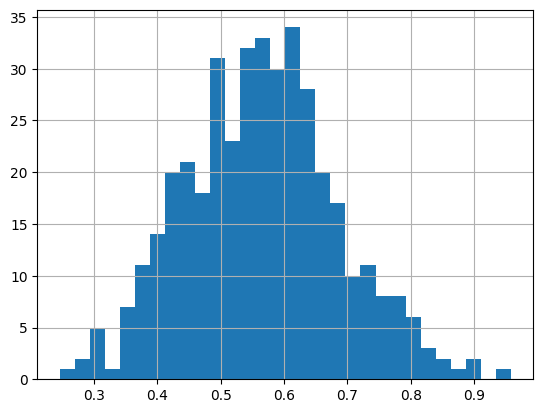

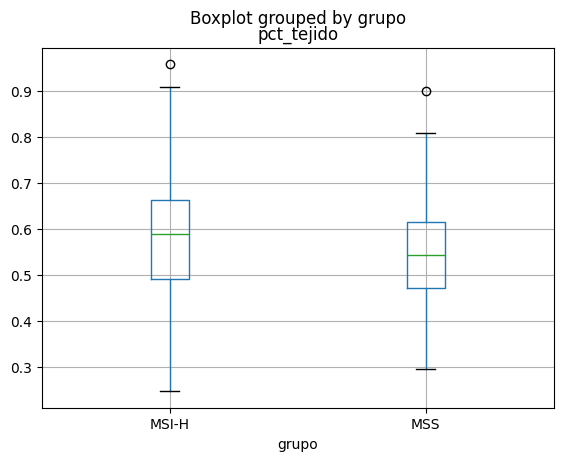

In [44]:
import pandas as pd

# arma un DataFrame con los datos del boxplot
df = pd.DataFrame({
    'pct_tejido': np.concatenate([mss, msih]),
    'grupo': ['MSS']*200 + ['MSI-H']*200
})

df['pct_tejido'].hist(bins=30)          # histograma en 1 línea
df.boxplot(column='pct_tejido', by='grupo')   # boxplot por grupo en 1 línea

/tmp/ipykernel_52808/3654759643.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([mss, msih], labels=['MSS', 'MSI-H'])


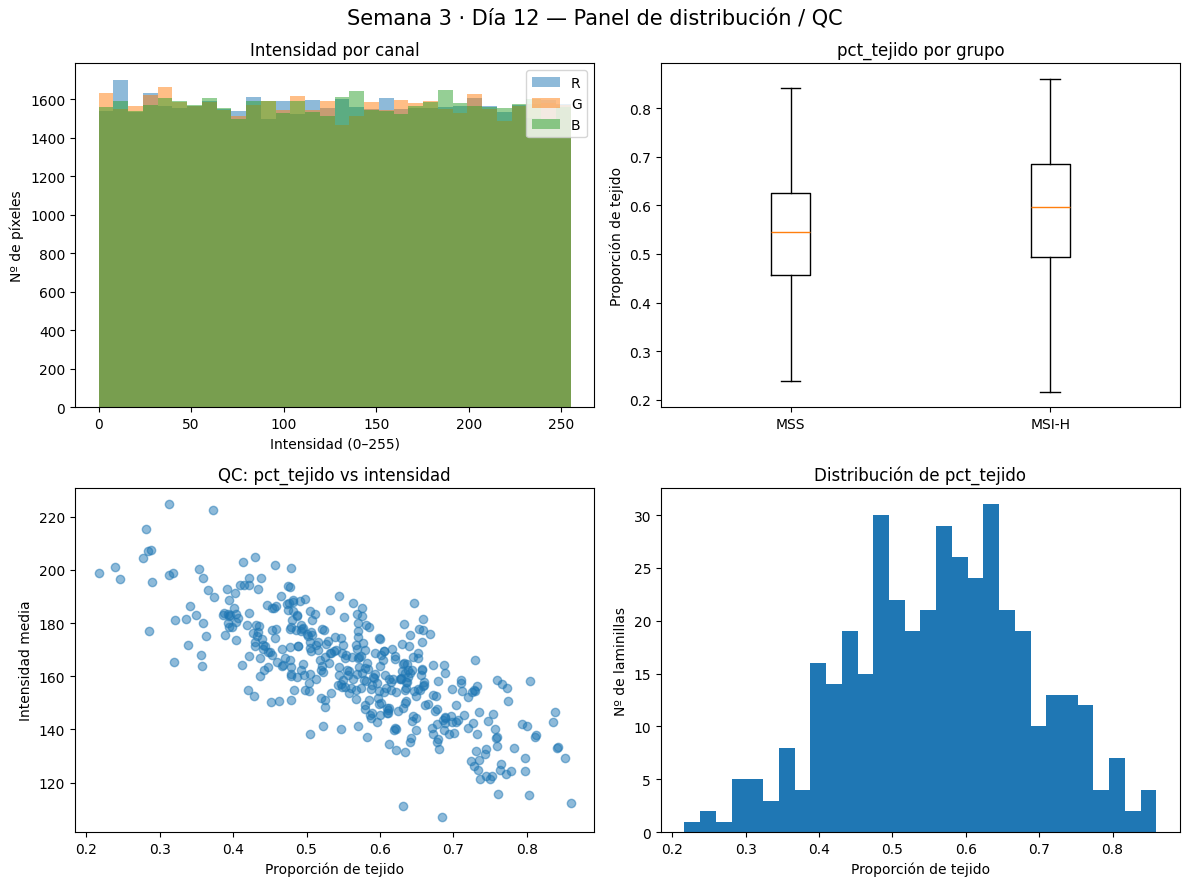

In [45]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)

# datos que ya tienes de hoy
parche = rng.integers(0, 256, size=(224, 224, 3), dtype=np.uint8)
mss  = rng.normal(0.55, 0.12, 200).clip(0, 1)
msih = rng.normal(0.58, 0.13, 200).clip(0, 1)
pct_tejido = np.concatenate([mss, msih])
intensidad = 230 - 120 * pct_tejido + rng.normal(0, 12, 400)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (0,0) histograma de intensidad por canal
for i, c in enumerate(['R', 'G', 'B']):
    axes[0, 0].hist(parche[:, :, i].ravel(), bins=32, alpha=0.5, label=c)
axes[0, 0].set_title('Intensidad por canal'); axes[0, 0].legend()
axes[0, 0].set_xlabel('Intensidad (0–255)'); axes[0, 0].set_ylabel('Nº de píxeles')
# (0,1) boxplot pct_tejido por grupo
axes[0, 1].boxplot([mss, msih], labels=['MSS', 'MSI-H'])
axes[0, 1].set_title('pct_tejido por grupo')
axes[0, 1].set_ylabel('Proporción de tejido')
# (1,0) dispersión pct_tejido vs intensidad
axes[1, 0].scatter(pct_tejido, intensidad, alpha=0.5)
axes[1, 0].set_title('QC: pct_tejido vs intensidad')
axes[1, 0].set_xlabel('Proporción de tejido'); axes[1, 0].set_ylabel('Intensidad media')
# (1,1) histograma de pct_tejido
axes[1, 1].hist(pct_tejido, bins=30)
axes[1, 1].set_title('Distribución de pct_tejido')
axes[1, 1].set_xlabel('Proporción de tejido'); axes[1, 1].set_ylabel('Nº de laminillas')
fig.suptitle('Semana 3 · Día 12 — Panel de distribución / QC', fontsize=15)
fig.tight_layout()

fig.savefig('results/fig_distribuciones_qc.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
axes[0, 0].set_xlabel('Intensidad (0–255)'); axes[0, 0].set_ylabel('Nº de píxeles')
axes[0, 1].set_ylabel('Proporción de tejido')
axes[1, 0].set_xlabel('Proporción de tejido'); axes[1, 0].set_ylabel('Intensidad media')
axes[1, 1].set_xlabel('Proporción de tejido'); axes[1, 1].set_ylabel('Nº de laminillas')

Text(627.9999999999999, 0.5, 'Nº de laminillas')

# **Día 13 — Buenas prácticas de visualización**

In [47]:
def aplicar_estilo():
    """Fija el estilo visual estándar del proyecto pathia-msi-colon.
    Llamar una vez al inicio de cada notebook, tras los imports."""
    plt.rcParams.update({
        'figure.dpi': 110,
        'savefig.dpi': 300,
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'axes.grid': True,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.figsize': (8, 5),
    })

aplicar_estilo()

In [48]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'clase_tejido': np.random.choice(
        ['TUM','STR','LYM','MUC','MUS','NORM','ADI','DEB','BACK'], 1000)
})

print(df.columns)   # confirma que aparece 'clase_tejido'
print(df.head())    # ojea las primeras filas

Index(['clase_tejido'], dtype='object')
  clase_tejido
0         NORM
1          MUC
2          STR
3         NORM
4          ADI


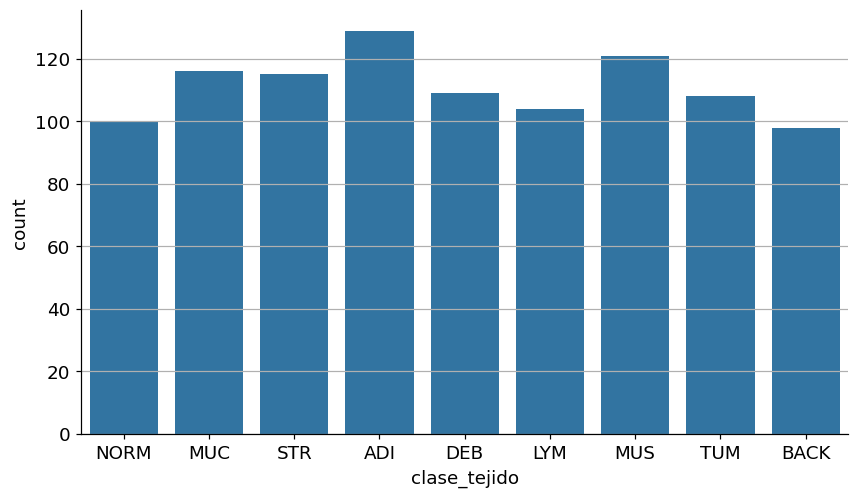

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# df tiene una columna 'clase_tejido' con etiquetas: TUM, STR, LYM, ...
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df, x='clase_tejido', ax=ax)
plt.show()

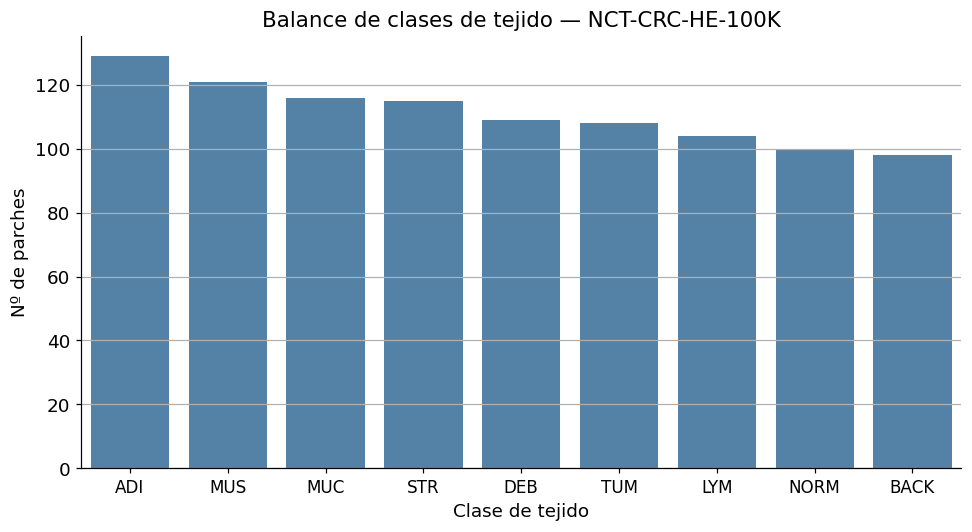

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

orden = df['clase_tejido'].value_counts().index

fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df, x='clase_tejido', order=orden, ax=ax, color='steelblue')

ax.set_title('Balance de clases de tejido — NCT-CRC-HE-100K', fontsize=14)
ax.set_xlabel('Clase de tejido', fontsize=12)
ax.set_ylabel('Nº de parches', fontsize=12)
ax.tick_params(axis='x', labelsize=11)

fig.tight_layout()
plt.show()